# PV Forecasting Benchmark

Example created by Wilson Rocha Lacerda Junior

> **Looking for more details on NARMAX models?**
> For comprehensive information on models, methods, and a wide range of examples and benchmarks implemented in SysIdentPy, check out our book:
> [*Nonlinear System Identification and Forecasting: Theory and Practice With SysIdentPy*](https://sysidentpy.org/book/0%20-%20Preface/)
>
> This book provides in-depth guidance to support your work with SysIdentPy.


## Reproducibility

This tutorial was verified with SysIdentPy 0.9.0 on Python 3.12.12,
`neuralprophet==0.9.0`, `torch==2.5.1`, pandas 2.3.3 and scikit-learn 1.7.2.
Data loaded from `sysidentpy-data` use an immutable commit URL. Randomized models
use an explicit seed.


## Note

The following example is **not** intended to say that one library is better than another. The main focus of these examples is to show that SysIdentPy can be a good alternative for people looking to model time series.

We will compare the results obtained against **neural prophet** library.

For the sake of brevity, from **SysIdentPy** only the **MetaMSS**, **AOLS** and **FROLS** (with polynomial base function) methods will be used. See the SysIdentPy documentation to learn other ways of modeling with the library.



We will compare a 1-step ahead forecaster on solar irradiance data (that can be a proxy for solar PV production). The config of the neuralprophet model was taken from the neuralprophet documentation (https://neuralprophet.com/html/example_links/energy_data_example.html)

The training will occur on 80% of the data, reserving the last 20% for the validation.

Note: the data used in this example can be found in neuralprophet github.


In [1]:
from warnings import simplefilter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sysidentpy.model_structure_selection import FROLS, AOLS, MetaMSS
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation import LeastSquares
from sysidentpy.utils.plotting import plot_results
from sysidentpy.metrics import mean_squared_error

from neuralprophet import NeuralProphet
from neuralprophet import set_random_seed

simplefilter("ignore", FutureWarning)
loss = mean_squared_error


def require_finite(name, values):
    if not np.isfinite(np.asarray(values)).all():
        raise FloatingPointError(f"{name} contains non-finite values.")


/private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


## FROLS


2204.333646698549


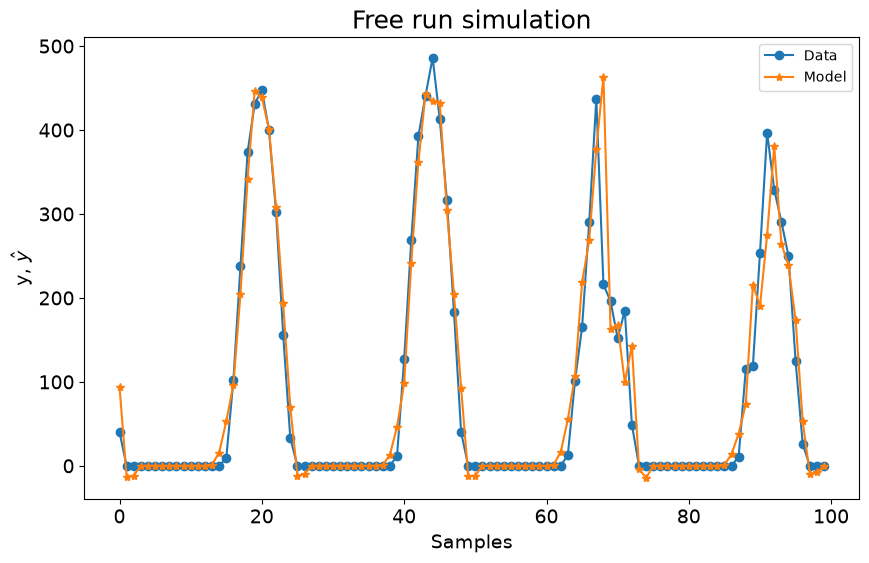

In [2]:
raw = pd.read_csv(
    "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/4085901293ba5ed5674bb2911ef4d1fa20f3438d/datasets/san_francisco_pv_ghi/SanFrancisco_PV_GHI.csv"
)
df = pd.DataFrame()
df["ds"] = pd.date_range("1/1/2015 1:00:00", freq=str(60) + "Min", periods=8760)
df["y"] = raw.iloc[:, 0].values

df_train, df_val = df.iloc[:7008, :], df.iloc[7008:, :]

y = df["y"].values.reshape(-1, 1)
y_train = df_train["y"].values.reshape(-1, 1)
y_test = df_val["y"].values.reshape(-1, 1)

x_train = df_train["ds"].dt.hour.values.reshape(-1, 1)
x_test = df_val["ds"].dt.hour.values.reshape(-1, 1)

basis_function = Polynomial(degree=1)
sysidentpy = FROLS(
    order_selection=True,
    ylag=24,
    xlag=24,
    info_criteria="bic",
    basis_function=basis_function,
    model_type="NARMAX",
    estimator=LeastSquares(),
)

sysidentpy.fit(X=x_train, y=y_train)
x_test = np.concatenate([x_train[-sysidentpy.max_lag :], x_test])
y_test = np.concatenate([y_train[-sysidentpy.max_lag :], y_test])

yhat = sysidentpy.predict(X=x_test, y=y_test, steps_ahead=1)
require_finite("FROLS predictions", yhat[sysidentpy.max_lag :])
sysidentpy_loss = loss(
    y_test[sysidentpy.max_lag :],
    yhat[sysidentpy.max_lag :],
)
print(sysidentpy_loss)

plot_results(y=y_test[-104:], yhat=yhat[-104:])

## MetaMSS


2154.2684027419573


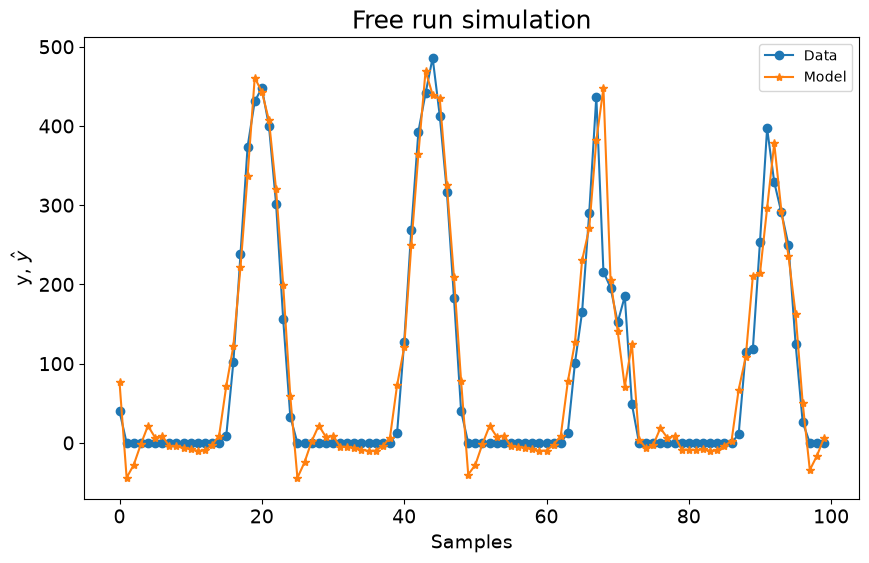

In [3]:
set_random_seed(42)
raw = pd.read_csv(
    "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/4085901293ba5ed5674bb2911ef4d1fa20f3438d/datasets/san_francisco_pv_ghi/SanFrancisco_PV_GHI.csv"
)
df = pd.DataFrame()
df["ds"] = pd.date_range("1/1/2015 1:00:00", freq=str(60) + "Min", periods=8760)
df["y"] = raw.iloc[:, 0].values

df_train, df_val = df.iloc[:7008, :], df.iloc[7008:, :]

y = df["y"].values.reshape(-1, 1)
y_train = df_train["y"].values.reshape(-1, 1)
y_test = df_val["y"].values.reshape(-1, 1)

x_train = df_train["ds"].dt.hour.values.reshape(-1, 1)
x_test = df_val["ds"].dt.hour.values.reshape(-1, 1)

basis_function = Polynomial(degree=1)
estimator = LeastSquares()
sysidentpy_metamss = MetaMSS(
    basis_function=basis_function,
    xlag=24,
    ylag=24,
    estimator=estimator,
    maxiter=10,
    steps_ahead=1,
    n_agents=15,
    loss_func="metamss_loss",
    model_type="NARMAX",
    random_state=42,
)
sysidentpy_metamss.fit(X=x_train, y=y_train)
x_test = np.concatenate([x_train[-sysidentpy_metamss.max_lag :], x_test])
y_test = np.concatenate([y_train[-sysidentpy_metamss.max_lag :], y_test])

yhat = sysidentpy_metamss.predict(X=x_test, y=y_test, steps_ahead=1)
require_finite("MetaMSS predictions", yhat[sysidentpy_metamss.max_lag :])
metamss_loss = loss(
    y_test[sysidentpy_metamss.max_lag :],
    yhat[sysidentpy_metamss.max_lag :],
)
print(metamss_loss)

plot_results(y=y_test[-104:], yhat=yhat[-104:])

## AOLS


2361.5616825473658


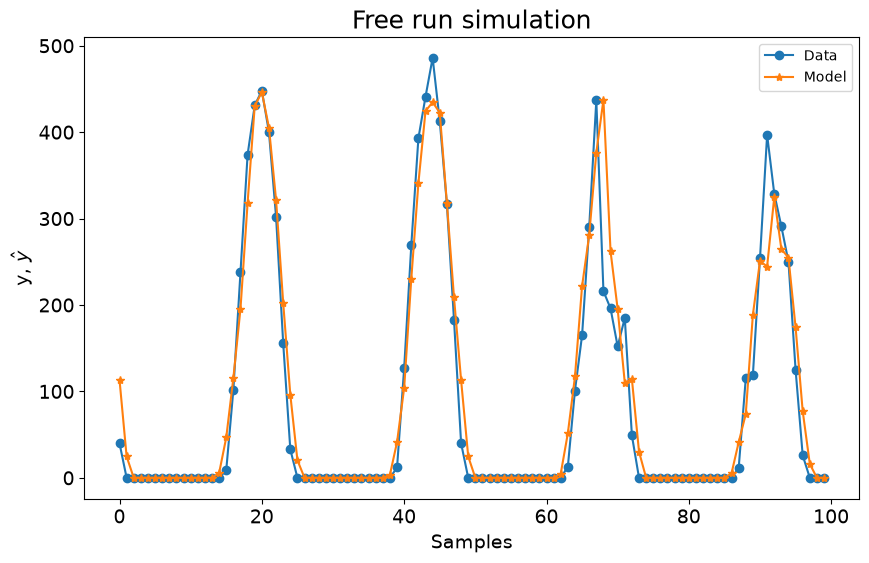

In [4]:
set_random_seed(42)
raw = pd.read_csv(
    "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/4085901293ba5ed5674bb2911ef4d1fa20f3438d/datasets/san_francisco_pv_ghi/SanFrancisco_PV_GHI.csv"
)
df = pd.DataFrame()
df["ds"] = pd.date_range("1/1/2015 1:00:00", freq=str(60) + "Min", periods=8760)
df["y"] = raw.iloc[:, 0].values

df_train, df_val = df.iloc[:7008, :], df.iloc[7008:, :]

y = df["y"].values.reshape(-1, 1)
y_train = df_train["y"].values.reshape(-1, 1)
y_test = df_val["y"].values.reshape(-1, 1)

x_train = df_train["ds"].dt.hour.values.reshape(-1, 1)
x_test = df_val["ds"].dt.hour.values.reshape(-1, 1)
basis_function = Polynomial(degree=1)
sysidentpy_AOLS = AOLS(
    ylag=24, xlag=24, k=2, L=1, model_type="NARMAX", basis_function=basis_function
)
sysidentpy_AOLS.fit(X=x_train, y=y_train)
x_test = np.concatenate([x_train[-sysidentpy_AOLS.max_lag :], x_test])
y_test = np.concatenate([y_train[-sysidentpy_AOLS.max_lag :], y_test])

yhat = sysidentpy_AOLS.predict(X=x_test, y=y_test, steps_ahead=1)
require_finite("AOLS predictions", yhat[sysidentpy_AOLS.max_lag :])
aols_loss = loss(
    y_test[sysidentpy_AOLS.max_lag :],
    yhat[sysidentpy_AOLS.max_lag :],
)
print(aols_loss)


plot_results(y=y_test[-104:], yhat=yhat[-104:])

## Neural Prophet


In [5]:
set_random_seed(42)

raw = pd.read_csv(
    "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/"
    "4085901293ba5ed5674bb2911ef4d1fa20f3438d/"
    "datasets/san_francisco_pv_ghi/SanFrancisco_PV_GHI.csv"
)
df = pd.DataFrame(
    {
        "ds": pd.date_range("2015-01-01 01:00:00", freq="h", periods=8760),
        "y": raw.iloc[:, 0].to_numpy(),
    }
)

m = NeuralProphet(
    n_lags=24, ar_reg=0.5, epochs=100, learning_rate=0.01
)
split = 7008
df_train, df_val = df.iloc[:split], df.iloc[split:]
m.fit(df_train, freq="h", progress=None)
prediction_df = pd.concat([df_train.tail(m.config_ar.n_lags), df_val])
forecast = m.predict(prediction_df)
valid = (forecast["ds"] >= df_val["ds"].min()) & np.isfinite(
    forecast["yhat1"].to_numpy()
)
if valid.sum() != len(df_val):
    raise RuntimeError("NeuralProphet did not predict every validation sample.")
require_finite("NeuralProphet predictions", forecast.loc[valid, "yhat1"])
neuralprophet_loss = loss(
    forecast.loc[valid, "y"].to_numpy(),
    forecast.loc[valid, "yhat1"].to_numpy(),
)
print(neuralprophet_loss)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.


INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.986% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h


INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


INFO - (NP.utils.set_auto_seasonalities) - Disabling yearly seasonality. Run NeuralProphet with yearly_seasonality=True to override this.


...

INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h


INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.944% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h


INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


2473.5396935912513


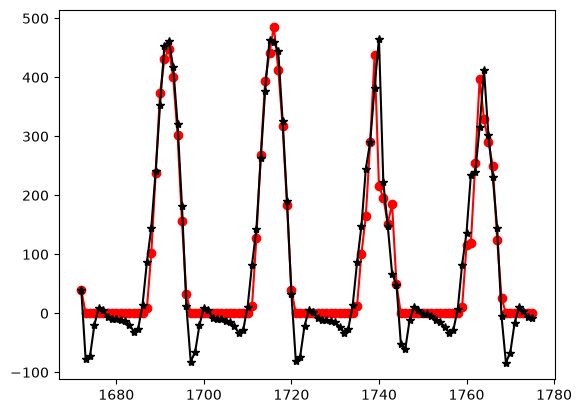

In [6]:
plt.plot(forecast["y"][-104:], "ro-")
plt.plot(forecast["yhat1"][-104:], "k*-")

## Reproduced results

The last 20% of the hourly series is used for validation. All four methods use a
24-sample autoregressive context and are compared by one-step-ahead MSE.

MetaMSS additionally reserves the final 25% of its 7,008-sample training block
for its chronological internal selection loss. The selected model is fitted on
the preceding internal identification segment; `fit` does not refit it on the
complete block.

| Method | MSE |
| --- | ---: |
| MetaMSS | 2154.2684 |
| FROLS | 2204.3336 |
| AOLS | 2361.5617 |
| NeuralProphet | 2473.5397 |

The comparison is specific to the stated models, seed and split; it does not imply
a general ranking of the libraries.